Code guide:
*   Section 0 (libraries) imports all necessary libraries for the entire code
*   Section 1 (data cleaning) cleans the raw data. Will output cleaned_data.xlsx and requires cleaned_data.xlsx to be imported
*   Section 2 (training models) trains multiple models using the cleaned data. Will output model files in .joblib format and requires cleaned_data.xlsx to be imported
*   Section 3 (model evaluation) provides metrics/importances of all models. Requires all .joblib files to be imported
*   Section 4 (deployment) runs the app deployment for our project. Requires cleaned_data.xlsx and all .joblib files to be imported

All kinds of importing involves uploading necessary files (either generated from previous section or saved) into the root of google colab files (not in any folders)


# 0. Libraries

In [ ]:
# Shell command (remove this in Python file)
!pip install streamlit

# Libraries
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import learning_curve

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.inspection import permutation_importance
from statsmodels.stats.outliers_influence import variance_inflation_factor

import joblib

# 1. Data Cleaning

In [ ]:
df = pd.read_excel('raw_data.xlsx')

### 1.1 Feature Selection & Understanding

Listing all features

In [ ]:
# Data information
print("\n--- DataFrame Info ---")
df.info()


--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 474330 entries, 0 to 474329
Data columns (total 94 columns):
 #   Column                                          Non-Null Count   Dtype  
---  ------                                          --------------   -----  
 0   id                                              474330 non-null  object 
 1   Company Common Name                             474150 non-null  object 
 2   Country of Headquarters                         474150 non-null  object 
 3   TRBC Economic Sector Name                       474150 non-null  object 
 4   Date of Incorporation                           457660 non-null  object 
 5   year of inc                                     457660 non-null  float64
 6   Contact City Address                            441170 non-null  object 
 7   ISIN                                            473140 non-null  object 
 8   RIC                                             474170 non-null  object 
 9   Bu

Unique identifiers:
* id and year (supposed to be company-year dataset)

Variables for model training:
* Independent: 17 SDGs (0 = No, 1 = Yes)
* Dependent: Total Revenue per Share
* Control: Total Assets and TRBC Industry Name

Additional variables for dashboard:
* Company Common Name
* Country of Headquarters

(The rest should be removed)

In [ ]:
# SDG Columns
sdg_cols = [
    'SDG 1 No Poverty', 'SDG 2 Zero Hunger', 'SDG 3 Good Health and Well-being',
    'SDG 4 Quality Education', 'SDG 5 Gender Equality', 'SDG 6 Clean Water and Sanitation',
    'SDG 7 Affordable and Clean Energy', 'SDG 8 Decent Work and Economic Growth',
    'SDG 9 Industry, Innovation and Infrastructure', 'SDG 10 Reduced Inequality',
    'SDG 11 Sustainable Cities and Communities', 'SDG 12 Responsible Consumption and Production',
    'SDG 13 Climate Action', 'SDG 14 Life Below Water', 'SDG 15 Life on Land',
    'SDG 16 Peace and Justice Strong Institutions', 'SDG 17 Partnerships to achieve the Goal'
]

# List of relevant columns
cols_to_keep = ['id', 'year', 'Company Common Name', 'Country of Headquarters',
                'TRBC Economic Sector Name', 'Total Assets', 'Total Revenue per Share'] + sdg_cols

# Keepign relevant columns
df = df[cols_to_keep]

Checking data distribution

In [ ]:
print("\n--- DataFrame Description ---")
df.describe()


--- DataFrame Description ---


,year,Total Assets,Total Revenue per Share,SDG 1 No Poverty,SDG 2 Zero Hunger,SDG 3 Good Health and Well-being,SDG 4 Quality Education,SDG 5 Gender Equality,SDG 6 Clean Water and Sanitation,SDG 7 Affordable and Clean Energy,SDG 8 Decent Work and Economic Growth,"SDG 9 Industry, Innovation and Infrastructure",SDG 10 Reduced Inequality,SDG 11 Sustainable Cities and Communities,SDG 12 Responsible Consumption and Production,SDG 13 Climate Action,SDG 14 Life Below Water,SDG 15 Life on Land,SDG 16 Peace and Justice Strong Institutions,SDG 17 Partnerships to achieve the Goal
count,474330.000000,3.701030e+05,3.512760e+05,49870.000000,49870.000000,49872.000000,49872.000000,49872.000000,49871.000000,49871.000000,49871.000000,49872.000000,49871.000000,49871.000000,49872.000000,49873.000000,49870.000000,49870.000000,49871.000000,49871.000000
mean,2019.500000,3.702382e+09,5.576409e+07,0.153479,0.124704,0.341815,0.285130,0.332010,0.221271,0.297869,0.409877,0.312279,0.258948,0.247278,0.379111,0.401760,0.128133,0.201745,0.239959,0.229592
std,2.872284,4.145971e+10,1.606230e+10,0.360452,0.330387,0.474323,0.451481,0.470939,0.415107,0.457326,0.491816,0.463428,0.438061,0.431434,0.485171,0.490259,0.334241,0.401307,0.427063,0.420575
min,2015.000000,-1.300000e+01,-1.428833e+06,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017.000000,1.674966e+07,1.007293e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2019.500000,1.053187e+08,7.102121e-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2022.000000,5.943407e+08,4.616913e+00,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,2024.000000,3.039193e+12,6.695700e+12,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Dependent variable (Total Revenue per Share) is insanely skewed, thus log-transforming and winsorization are necessary

### 1.2. Treating duplicates

Based from UID defined (id and year)

In [ ]:
duplicates = df.duplicated(subset=["id", "year"]) # Based from id and year
num_duplicates = duplicates.sum() # Check number of duplicates
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 200


Confirmed there are duplicates in the dataset

Keep only the first instance of each duplicates since it is rare and it won't alter the results much

In [ ]:
df = df.drop_duplicates(subset=['id','year'], keep='first') # Remove duplicates

### 1.3. Missing values

Check number of missing values in each feature

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 474130 entries, 0 to 474329
Data columns (total 24 columns):
 #   Column                                         Non-Null Count   Dtype  
---  ------                                         --------------   -----  
 0   id                                             474130 non-null  object 
 1   year                                           474130 non-null  int64  
 2   Company Common Name                            474060 non-null  object 
 3   Country of Headquarters                        474060 non-null  object 
 4   TRBC Economic Sector Name                      474060 non-null  object 
 5   Total Assets                                   370048 non-null  float64
 6   Total Revenue per Share                        351223 non-null  float64
 7   SDG 1 No Poverty                               49856 non-null   float64
 8   SDG 2 Zero Hunger                              49856 non-null   float64
 9   SDG 3 Good Health and Well-being          

Majority of missing values is in the SDGs.

Since it is our only predictors, keeping rows with complete data is necessary to valid model training.

In [ ]:
initial_rows = df.shape[0] # Tracking purposes
df = df.dropna() # Dropping any rows with any NA
final_rows = df.shape[0]
df = df.reset_index(drop=True)

print(f"Rows reduced: {initial_rows} → {final_rows}")

Rows reduced: 474130 → 49031


We may have lost many rows (around 88%), but what remains would still be enough for model training.

### 1.4. Logical consistency

Removing any rows with invalid values

In [ ]:
numeric_cols = ['Total Revenue per Share', 'Total Assets']
required_cols = numeric_cols + sdg_cols

for col in numeric_cols:
    df = df[df[col] >= 0]  # Remove negative values

for col in sdg_cols:
    df = df[(df[col] == 0) | (df[col] == 1)] # Remove invalid SDGs values

df = df.reset_index(drop=True)

### 1.5. Correcting data types

Change SDGs values to integer (right now it's in decimal)

In [ ]:
df.head(5)

,id,year,Company Common Name,Country of Headquarters,TRBC Economic Sector Name,Total Assets,Total Revenue per Share,SDG 1 No Poverty,SDG 2 Zero Hunger,SDG 3 Good Health and Well-being,...,SDG 8 Decent Work and Economic Growth,"SDG 9 Industry, Innovation and Infrastructure",SDG 10 Reduced Inequality,SDG 11 Sustainable Cities and Communities,SDG 12 Responsible Consumption and Production,SDG 13 Climate Action,SDG 14 Life Below Water,SDG 15 Life on Land,SDG 16 Peace and Justice Strong Institutions,SDG 17 Partnerships to achieve the Goal
0,000002.SZ,2018,China Vanke Co Ltd,China,Real Estate,2.223230e+11,3.655745,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,000002.SZ,2019,China Vanke Co Ltd,China,Real Estate,2.484890e+11,4.332606,0.0,0.0,1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0
2,000002.SZ,2020,China Vanke Co Ltd,China,Real Estate,2.864639e+11,5.282174,0.0,0.0,1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0
3,000002.SZ,2021,China Vanke Co Ltd,China,Real Estate,3.051964e+11,5.887922,0.0,0.0,1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0
4,000002.SZ,2022,China Vanke Co Ltd,China,Real Estate,2.548580e+11,6.037372,0.0,0.0,1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0


In [ ]:
df[sdg_cols] = df[sdg_cols].astype(int)

### 1.6. Outlier removal

Removing any potential outliers from the target variable using log-transformation and winsorization

In [ ]:
# Log transform
df["Total Revenue per Share"] = np.log1p(df["Total Revenue per Share"])

# Winsorization
upper_bound = df["Total Revenue per Share"].quantile(0.99)
lower_bound = df["Total Revenue per Share"].quantile(0.01)
df = df[(df["Total Revenue per Share"] <= upper_bound) & (df["Total Revenue per Share"] >= lower_bound)]

### 1.7. Save df for visualization

Cleaning the SDG column names for visualization

In [ ]:
df2 = df.copy()

sdg_mapping = {
    "SDG 1 No Poverty": "SDG1",
    "SDG 2 Zero Hunger": "SDG2",
    "SDG 3 Good Health and Well-being": "SDG3",
    "SDG 4 Quality Education": "SDG4",
    "SDG 5 Gender Equality": "SDG5",
    "SDG 6 Clean Water and Sanitation": "SDG6",
    "SDG 7 Affordable and Clean Energy": "SDG7",
    "SDG 8 Decent Work and Economic Growth": "SDG8",
    "SDG 9 Industry, Innovation and Infrastructure": "SDG9",
    "SDG 10 Reduced Inequality": "SDG10",
    "SDG 11 Sustainable Cities and Communities": "SDG11",
    "SDG 12 Responsible Consumption and Production": "SDG12",
    "SDG 13 Climate Action": "SDG13",
    "SDG 14 Life Below Water": "SDG14",
    "SDG 15 Life on Land": "SDG15",
    "SDG 16 Peace and Justice Strong Institutions": "SDG16",
    "SDG 17 Partnerships to achieve the Goal": "SDG17"
}

df2.rename(columns=sdg_mapping, inplace=True)

Save current dataframe to .xlsx file for dashboard and EDA purposes

In [ ]:
df2.to_excel("cleaned_data.xlsx", index=False)

# 2. Training Models

Section where all model training goes here

In [ ]:
# Load data
df = pd.read_excel('cleaned_data.xlsx')

# Removing features exclusively for dashboard purposes
df = df.drop(columns=["id", "year", "Company Common Name", "Country of Headquarters"])

df.head(5)

,TRBC Economic Sector Name,Total Assets,Total Revenue per Share,SDG1,SDG2,SDG3,SDG4,SDG5,SDG6,SDG7,SDG8,SDG9,SDG10,SDG11,SDG12,SDG13,SDG14,SDG15,SDG16,SDG17
0,Real Estate,2.223230e+11,1.538102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,Real Estate,2.484890e+11,1.673840,0,0,1,1,1,0,0,1,1,0,1,1,1,0,1,0,1
2,Real Estate,2.864639e+11,1.837716,0,0,1,1,1,0,0,1,1,0,1,1,1,0,1,0,1
3,Real Estate,3.051964e+11,1.929769,0,0,1,1,1,0,0,1,1,0,1,1,1,0,1,0,1
4,Real Estate,2.548580e+11,1.951235,0,0,1,1,1,0,0,1,1,0,1,1,1,0,1,0,1


In [ ]:
df.describe()

,Total Assets,Total Revenue per Share,SDG1,SDG2,SDG3,SDG4,SDG5,SDG6,SDG7,SDG8,SDG9,SDG10,SDG11,SDG12,SDG13,SDG14,SDG15,SDG16,SDG17
count,4.786600e+04,47866.000000,47866.000000,47866.000000,47866.000000,47866.000000,47866.000000,47866.000000,47866.000000,47866.000000,47866.000000,47866.000000,47866.000000,47866.000000,47866.000000,47866.000000,47866.000000,47866.000000,47866.000000
mean,2.057629e+10,1.918860,0.156082,0.126227,0.346843,0.290269,0.337839,0.225024,0.303117,0.416120,0.317052,0.262566,0.252267,0.385096,0.408307,0.130468,0.204341,0.244328,0.234070
std,1.050854e+11,1.483936,0.362936,0.332109,0.475970,0.453891,0.472978,0.417603,0.459610,0.492919,0.465333,0.440033,0.434318,0.486623,0.491526,0.336822,0.403224,0.429692,0.423421
min,4.008114e+05,0.003069,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.389823e+08,0.596098,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.676075e+09,1.641744,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.519379e+09,3.061943,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,3.039193e+12,6.165420,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# Split features and target
X = df.drop(["TRBC Economic Sector Name", "Total Assets", "Total Revenue per Share"], axis=1)
y = df["Total Revenue per Share"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Function to train and evaluate pipelines
def train_and_eval(pipeline, name):
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    print(f"{name} R^2 score: {score:.4f}")

Training linear regression model

In [ ]:
# Builidng LR pipeline
lr_pipeline = Pipeline([
    ("regressor", LinearRegression())
])
train_and_eval(lr_pipeline, "LR")

# Save model as .joblib file
joblib.dump(lr_pipeline, "lr_pipeline.joblib")
print("Best model saved to lr_pipeline.joblib")

LR R^2 score: 0.0184
Best model saved to lr_pipeline.joblib


R2 is very low here...

In [ ]:
# Building random forest pipeline
rf_pipeline = Pipeline([
    ("regressor", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

# Hypertuning
param_dist = {
    "regressor__n_estimators": [200, 400, 500, 800],
    "regressor__max_depth": [None, 5, 8, 12, 15],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4],
    "regressor__max_features": [3, 5, 8],
    "regressor__bootstrap": [True, False]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)
best_rf = rf_search.fit(X_train, y_train).best_estimator_

# Evaluate
score = best_rf.score(X_test, y_test)
print(f"Best Random Forest R^2 on test set: {score:.4f}")

# Print best params
print("\nBest hyperparameters:")
for k, v in rf_search.best_params_.items():
    print(f"{k}: {v}")

# Save model as .joblib file
joblib.dump(best_rf, "rf_pipeline.joblib")
print("Best Random Forest saved to rf_pipeline.joblib")


Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best Random Forest R^2 on test set: 0.1159

Best hyperparameters:
regressor__n_estimators: 200
regressor__min_samples_split: 2
regressor__min_samples_leaf: 1
regressor__max_features: 8
regressor__max_depth: 15
regressor__bootstrap: False
Best Random Forest saved to rf_pipeline.joblib


Performs better than LR, but still a terrible performance

Trying another model (XGBoost)

In [ ]:
# Building XGBoost pipeline
xgb_pipeline = Pipeline([
    ("regressor", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

# Hyperparams
param_dist = {
    "regressor__n_estimators": [300, 500, 800, 1200],
    "regressor__max_depth": [3, 4, 6, 8],
    "regressor__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "regressor__subsample": [0.6, 0.8, 1.0],
    "regressor__colsample_bytree": [0.6, 0.8, 1.0],
    "regressor__min_child_weight": [1, 3, 5, 7],
    "regressor__gamma": [0, 0.1, 0.3, 0.5]
}

search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Evaluation
search.fit(X_train, y_train)
xgb_model = search.best_estimator_

r2 = xgb_model.score(X_test, y_test)
print(f"Best XGBoost R^2 on test set: {r2:.4f}")

# Best hyperparameters
print("\nBest hyperparameters:")
for k, v in search.best_params_.items():
    print(f"{k}: {v}")

# Save model as .joblib file
joblib.dump(xgb_model, "xgb_pipeline.joblib")
print("\nBest XGBoost model saved to xgb_pipeline.joblib")

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best XGBoost R^2 on test set: -10602.8380

Best hyperparameters:
regressor__subsample: 0.6
regressor__n_estimators: 300
regressor__min_child_weight: 7
regressor__max_depth: 4
regressor__learning_rate: 0.03
regressor__gamma: 0
regressor__colsample_bytree: 1.0

Best XGBoost model saved to xgb_pipeline.joblib


Performs the best compared to RF and LR

In terms of R2, still terrible

Now let's include the control variables (XGBoost)

In [ ]:
# Split new features and target
X2 = df.drop(["Total Revenue per Share"], axis=1)
y2 = df["Total Revenue per Share"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Building advanced pipeline
num_features = X_train2.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_features.remove("Total Assets")

cat_features = ["TRBC Economic Sector Name"]

total_assets_pipeline = Pipeline([
    ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])
numeric_pipeline = "passthrough"
categorical_pipeline = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer([
    ("total_assets", total_assets_pipeline, ["Total Assets"]),
    ("num", numeric_pipeline, num_features),
    ("cat", categorical_pipeline, cat_features)
])

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

# Hypertuning
param_dist = {
    "regressor__n_estimators": [300, 500, 800],
    "regressor__max_depth": [3, 4, 6, 8],
    "regressor__learning_rate": [0.01, 0.05, 0.1],
    "regressor__subsample": [0.6, 0.8, 1.0],
    "regressor__colsample_bytree": [0.6, 0.8, 1.0],
    "regressor__min_child_weight": [1, 3, 5],
    "regressor__gamma": [0, 0.1, 0.3]
}
search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Evaluation
search.fit(X_train2, y_train2)

xgb_model_plus = search.best_estimator_

r2 = xgb_model_plus.score(X_test2, y_test2)
print(f"Best XGBoost R^2 on test set: {r2:.4f}")

# Best hyperparams
print("\nBest hyperparameters:")
for k, v in search.best_params_.items():
    print(f"{k}: {v}")

# Save model as .joblib file
joblib.dump(xgb_model_plus, "xgb_pipeline_plus.joblib")
print("\nBest XGBoost model saved to xgb_pipeline_plus.joblib")


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best XGBoost R^2 on test set: -5188797.7476

Best hyperparameters:
regressor__subsample: 0.6
regressor__n_estimators: 300
regressor__min_child_weight: 5
regressor__max_depth: 3
regressor__learning_rate: 0.01
regressor__gamma: 0.3
regressor__colsample_bytree: 0.8

Best XGBoost model saved to xgb_pipeline_plus.joblib


Huge imporvement, thus the control variables determines the revenue much better compared to SDG indicators alone

# 3. Model Evaluation

### Pre-requisite

In [ ]:
# Pre-requisite if previous section is skipped and user only uploads the file required
df = pd.read_excel('cleaned_data.xlsx')
df = df.drop(columns=["id", "year", "Company Common Name", "Country of Headquarters"])

X = df.drop(["TRBC Economic Sector Name", "Total Assets", "Total Revenue per Share"], axis=1)
y = df["Total Revenue per Share"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X2 = df.drop(["Total Revenue per Share"], axis=1)
y2 = df["Total Revenue per Share"]
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

### Linear Regression without control variables

Metrics and Coefficients

In [ ]:
lr_model = joblib.load("lr_pipeline.joblib")

score = lr_model.score(X_test, y_test)
print(f"Best Linear Regression R^2 on test set: {score:.4f}\n")

# Print the coefficients
coefficients = lr_model.named_steps["regressor"].coef_
intercept = lr_model.named_steps["regressor"].intercept_

print("Coefficients:")
for feature, coef in zip(X_train.columns, coefficients):
    print(f"{feature}: {coef:.4f}")
print(f"Intercept = {intercept:.4f}")

print("NOTE: Formula format:")
print("log_revenue = (SDG1 value) * (SDG1 coef) + ....")

Best Linear Regression R^2 on test set: 0.0184

Coefficients:
SDG1: -0.4424
SDG2: 0.1808
SDG3: -0.1061
SDG4: 0.0124
SDG5: 0.1023
SDG6: -0.0331
SDG7: 0.1213
SDG8: -0.1192
SDG9: -0.0316
SDG10: -0.0297
SDG11: -0.2285
SDG12: 0.1578
SDG13: 0.2521
SDG14: 0.2105
SDG15: 0.0479
SDG16: -0.2860
SDG17: 0.0040
Intercept = 1.9307
NOTE: Formula format:
log_revenue = (SDG1 value) * (SDG1 coef) + ....


Learning plot

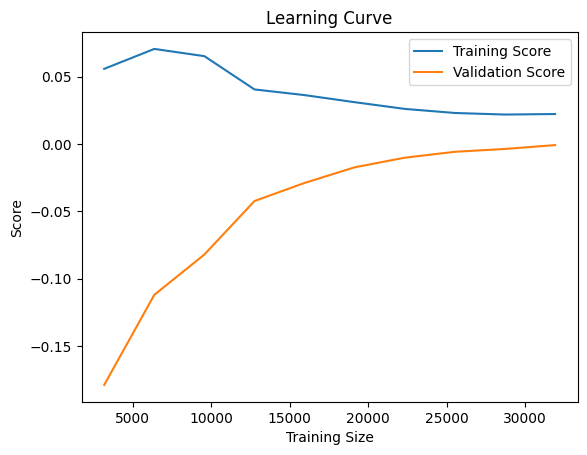

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    lr_model, X, y,
    cv=3,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("Score")
plt.legend()
plt.title("Learning Curve")
plt.show()


VIF testing

In [ ]:
# Add constant for VIF calculation
X_vif = X.copy()
X_vif["Intercept"] = 1

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

print(vif_data)

      Feature       VIF
0        SDG1  2.020960
1        SDG2  1.754964
2        SDG3  2.884641
3        SDG4  2.441685
4        SDG5  3.027191
5        SDG6  2.081993
6        SDG7  2.616589
7        SDG8  4.873085
8        SDG9  2.623472
9       SDG10  2.310928
10      SDG11  2.056054
11      SDG12  3.928158
12      SDG13  4.542214
13      SDG14  1.698223
14      SDG15  2.159417
15      SDG16  2.073348
16      SDG17  1.944497
17  Intercept  1.785576


Homoscedasticity Test

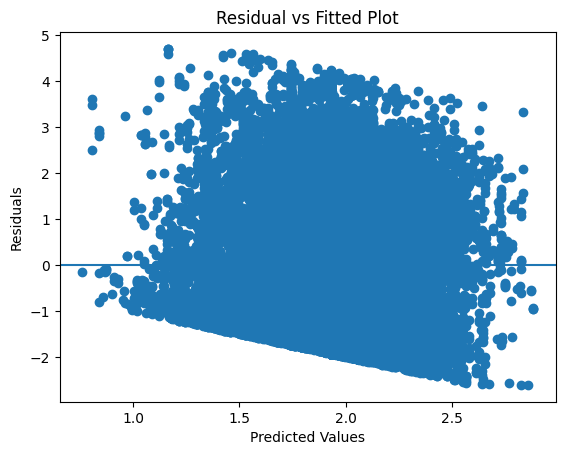

In [ ]:
# Get predictions and residuals
y_pred = lr_model.predict(X)
residuals = y - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual vs Fitted Plot")
plt.show()

### Random Forest without control variables

##### Metrics and Params

In [ ]:
best_rf = joblib.load("rf_pipeline.joblib")

score = best_rf.score(X_test, y_test)
print(f"Best Random Forest R^2 on test set: {score:.4f}\n")
params = best_rf.get_params()
print("Parameters:")
for k, v in params.items():
    print(k, ":", v)

Best Random Forest R^2 on test set: 0.1168

Parameters:
memory : None
steps : [('regressor', RandomForestRegressor(bootstrap=False, max_depth=15, max_features=8,
                      min_samples_split=5, n_estimators=800, n_jobs=-1,
                      random_state=42))]
transform_input : None
verbose : False
regressor : RandomForestRegressor(bootstrap=False, max_depth=15, max_features=8,
                      min_samples_split=5, n_estimators=800, n_jobs=-1,
                      random_state=42)
regressor__bootstrap : False
regressor__ccp_alpha : 0.0
regressor__criterion : squared_error
regressor__max_depth : 15
regressor__max_features : 8
regressor__max_leaf_nodes : None
regressor__max_samples : None
regressor__min_impurity_decrease : 0.0
regressor__min_samples_leaf : 1
regressor__min_samples_split : 5
regressor__min_weight_fraction_leaf : 0.0
regressor__monotonic_cst : None
regressor__n_estimators : 800
regressor__n_jobs : -1
regressor__oob_score : False
regressor__random_state 

##### Feature Importance

In [ ]:
rf_model = best_rf.named_steps['regressor']
feature_names = X_train.columns
importances = rf_model.feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})
feat_imp = feat_imp.sort_values(by='importance', ascending=False)
print(feat_imp.head(20))

   feature  importance
16   SDG17    0.076923
3     SDG4    0.076894
8     SDG9    0.074772
4     SDG5    0.073968
9    SDG10    0.070424
5     SDG6    0.070333
6     SDG7    0.070234
14   SDG15    0.067132
2     SDG3    0.066933
13   SDG14    0.051980
11   SDG12    0.049902
7     SDG8    0.049691
1     SDG2    0.046797
10   SDG11    0.045590
15   SDG16    0.038286
0     SDG1    0.036038
12   SDG13    0.034105


##### Permutation Importance

In [ ]:
perm = permutation_importance(
    best_rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Convert to dataframe
feat_imp_perm = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm.importances_mean
})

feat_imp_perm = feat_imp_perm.sort_values(by='importance', ascending=False)

print(feat_imp_perm.head(20))

   feature  importance
0     SDG1    0.160628
11   SDG12    0.107810
4     SDG5    0.107498
2     SDG3    0.105372
8     SDG9    0.094309
15   SDG16    0.092589
12   SDG13    0.086662
6     SDG7    0.085591
10   SDG11    0.082179
14   SDG15    0.078501
3     SDG4    0.075832
9    SDG10    0.060804
5     SDG6    0.060376
13   SDG14    0.059811
16   SDG17    0.059526
1     SDG2    0.056284
7     SDG8    0.045232


Learning Plot

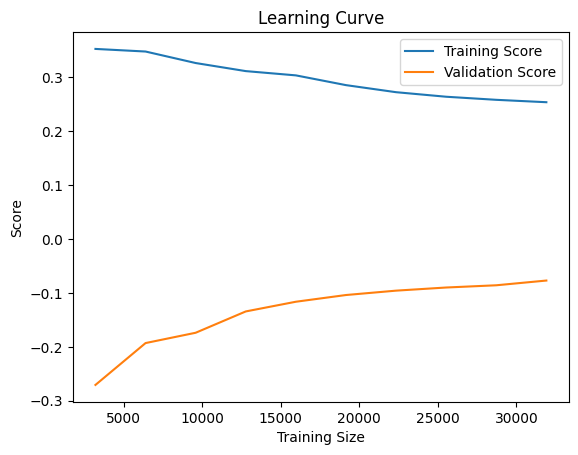

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    rf_model, X, y,
    cv=3,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("Score")
plt.legend()
plt.title("Learning Curve")
plt.show()


### XGBoost model without control variables

##### Metrics and Params

In [ ]:
xgb_model = joblib.load("xgb_pipeline.joblib")

score = xgb_model.score(X_test, y_test)
print(f"Best XGBoost R^2 on test set: {score:.4f}\n")
print("Parameters:")
print(xgb_model.get_params())

/usr/lib/python3.12/pickle.py:1760: UserWarning: [15:26:00] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


Best XGBoost R^2 on test set: 0.0928

Parameters:
{'memory': None, 'steps': [('regressor', XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1200,
             n_jobs=-1, num_parallel_tree=None, ...))], 'transform_input': None, 'verbose': False, 'regressor': XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_byn

##### Feature Importance

In [ ]:
xgb_trained = xgb_model.named_steps['regressor']
feature_names = X_train.columns

importances = xgb_trained.feature_importances_
feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

feat_imp = feat_imp.sort_values(by='importance', ascending=False)
print(feat_imp.head(20))

   feature  importance
0     SDG1    0.062597
1     SDG2    0.060990
2     SDG3    0.059837
7     SDG8    0.059472
4     SDG5    0.059299
11   SDG12    0.059056
15   SDG16    0.058998
3     SDG4    0.058970
13   SDG14    0.058733
16   SDG17    0.058601
14   SDG15    0.058476
5     SDG6    0.058262
8     SDG9    0.058256
6     SDG7    0.057955
10   SDG11    0.057921
9    SDG10    0.056659
12   SDG13    0.055916


##### Permutation Importance

In [ ]:
result = permutation_importance(
    xgb_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_imp = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

perm_imp

,feature,importance
0,SDG1,0.145262
4,SDG5,0.123480
11,SDG12,0.123423
2,SDG3,0.120864
8,SDG9,0.119185
3,SDG4,0.090913
14,SDG15,0.090487
12,SDG13,0.089143
6,SDG7,0.086350
15,SDG16,0.085310


Learning Plot

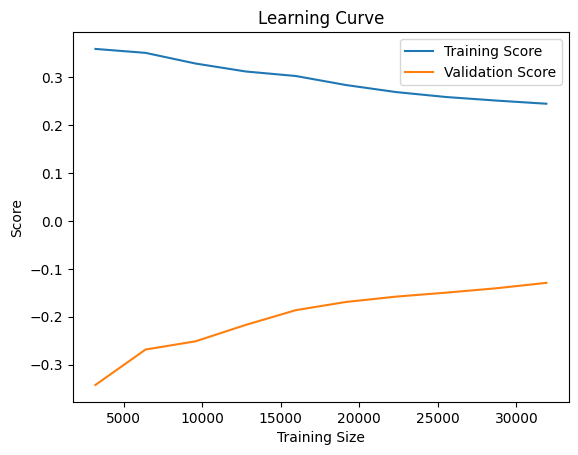

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    xgb_model, X, y,
    cv=3,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("Score")
plt.legend()
plt.title("Learning Curve")
plt.show()


### XGBoost model with control variables

##### Metrics and Params

In [ ]:
# Load trained pipeline
xgb_model_plus = joblib.load("xgb_pipeline_plus.joblib")

score = xgb_model_plus.score(X_test2, y_test2)
print(f"Best XGBoost R^2 on test set: {score:.4f}\n")
print("Parameters:")
print(xgb_model_plus.get_params())

Best XGBoost R^2 on test set: 0.3641

Parameters:
{'memory': None, 'steps': [('preprocessor', ColumnTransformer(transformers=[('total_assets',
                                 Pipeline(steps=[('log',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>)),
                                                 ('scaler', StandardScaler())]),
                                 ['Total Assets']),
                                ('num', 'passthrough',
                                 ['SDG1', 'SDG2', 'SDG3', 'SDG4', 'SDG5',
                                  'SDG6', 'SDG7', 'SDG8', 'SDG9', 'SDG10',
                                  'SDG11', 'SDG12', 'SDG13', 'SDG14', 'SDG15',
                                  'SDG16', 'SDG17']),
                                ('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                      

##### Feature Importance

In [ ]:
# Extract components
xgb_trained = xgb_model_plus.named_steps["regressor"]
preprocessor = xgb_model_plus.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()

# Feature importances
importances = xgb_trained.feature_importances_

# Create DataFrame
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sort descending
feat_imp = feat_imp.sort_values(by="importance", ascending=False)

# Show top 20
print(feat_imp.head(20))
print(feat_imp)

                                              feature  importance
26         cat__TRBC Economic Sector Name_Real Estate    0.164594
20  cat__TRBC Economic Sector Name_Consumer Cyclicals    0.111904
23          cat__TRBC Economic Sector Name_Financials    0.108772
25         cat__TRBC Economic Sector Name_Industrials    0.070581
28           cat__TRBC Economic Sector Name_Utilities    0.059324
0                          total_assets__Total Assets    0.040879
24          cat__TRBC Economic Sector Name_Healthcare    0.038979
21  cat__TRBC Economic Sector Name_Consumer Non-Cy...    0.032193
27          cat__TRBC Economic Sector Name_Technology    0.027458
19     cat__TRBC Economic Sector Name_Basic Materials    0.025653
18  cat__TRBC Economic Sector Name_Academic & Educ...    0.022001
22              cat__TRBC Economic Sector Name_Energy    0.021545
1                                           num__SDG1    0.020019
11                                         num__SDG11    0.018674
16        

##### Permutation Importance

In [ ]:
result = permutation_importance(
    xgb_model_plus,
    X_test2,
    y_test2,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_imp = pd.DataFrame({
    'feature': X_test2.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

perm_imp

,feature,importance
0,TRBC Economic Sector Name,0.448236
1,Total Assets,0.417460
2,SDG1,0.061348
13,SDG12,0.053532
8,SDG7,0.048932
6,SDG5,0.038635
9,SDG8,0.035990
10,SDG9,0.035601
14,SDG13,0.034646
5,SDG4,0.034175


Learning Plot

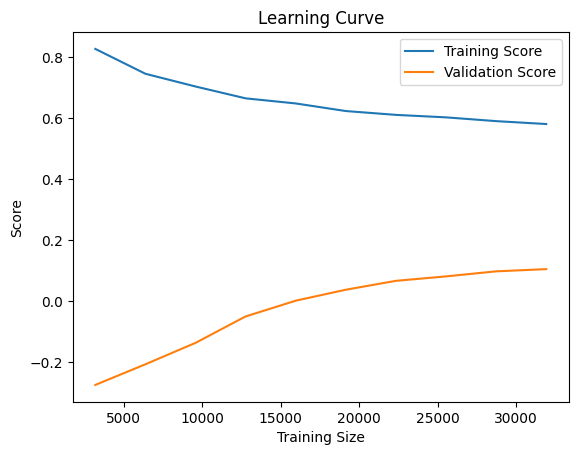

In [ ]:
train_sizes, train_scores, val_scores = learning_curve(
    xgb_model_plus, X2, y2,
    cv=3,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("Score")
plt.legend()
plt.title("Learning Curve")
plt.show()


# 4. Deployment

In [ ]:
lr_model = joblib.load("lr_pipeline.joblib")
rf_model = joblib.load("rf_pipeline.joblib")
xgb_model = joblib.load("xgb_pipeline.joblib")
xgb2_model = joblib.load("xgb_pipeline_plus.joblib")

cleaned_df = pd.read_excel("cleaned_data.xlsx")
preview_df = cleaned_df[
    (cleaned_df["Country of Headquarters"] == "Malaysia")
]

# MODEL DATA
model_information = {
    "LR": {"R2": 0.0184, "RMSE": 1.4768, "MAE": 1.2512, "coeffs": {
        "SDG1": -0.4424, "SDG2": 0.1808, "SDG3": -0.1061, "SDG4": 0.0124, "SDG5": 0.1023,
        "SDG6": -0.0331, "SDG7": 0.1213, "SDG8": -0.1192, "SDG9": -0.0316, "SDG10": -0.0297,
        "SDG11": -0.2285, "SDG12": 0.1578, "SDG13": 0.2521, "SDG14": 0.2105, "SDG15": 0.0479,
        "SDG16": -0.2860, "SDG17": 0.0040, "Intercept": 1.9307
        },
    },
    "RF": {"R2": 0.1168, "RMSE": 1.4008, "MAE": 1.1431, "params": {
        "n_estimators": 200, "min_samples_split": 2, "min_samples_leaf": 1,
        "max_features": 8, "max_depth": 15, "bootstrap": False,
    }, "f_importance": {
        "SDG1": 0.0360, "SDG2": 0.0468, "SDG3": 0.0341, "SDG4": 0.0769, "SDG5": 0.0740,
        "SDG6": 0.0703, "SDG7": 0.0702, "SDG8": 0.0497, "SDG9": 0.0747, "SDG10": 0.0704,
        "SDG11": 0.0456, "SDG12": 0.0499, "SDG13": 0.2521, "SDG14": 0.0519, "SDG15": 0.0671,
        "SDG16": 0.0383, "SDG17": 0.0769
    }, "p_importance": {
        "SDG1": 0.1606, "SDG2": 0.0563, "SDG3": 0.1054, "SDG4": 0.0758, "SDG5": 0.1075,
        "SDG6": 0.0604, "SDG7": 0.0856, "SDG8": 0.0452, "SDG9": 0.0943, "SDG10": 0.0608,
        "SDG11": 0.0822, "SDG12": 0.1078, "SDG13": 0.0867, "SDG14": 0.0598, "SDG15": 0.0785,
        "SDG16": 0.0926, "SDG17": 0.0595
    }},
    "XGB": {"R2": 0.0928, "RMSE": 1.4197, "MAE": 1.1571, "params": {
        "n_estimators": 300, "sub_sample": 0.6, "min_child_weight": 7, "max_depth": 4, "learning_rate": 0.03,
        "gamma": 0, "colsample_bytree": 1.0
    }, "f_importance": {
        "SDG1": 0.062597, "SDG2": 0.060990, "SDG3": 0.059837, "SDG8": 0.059472, "SDG5": 0.059299,
        "SDG12": 0.059056, "SDG16": 0.058998, "SDG4": 0.058970, "SDG14": 0.058733, "SDG17": 0.058601,
        "SDG15": 0.058476, "SDG6": 0.058262, "SDG9": 0.058256, "SDG7": 0.057955, "SDG11": 0.057921,
        "SDG10": 0.056659, "SDG13": 0.055916
    }, "p_importance": {
        "SDG1": 0.145262, "SDG5": 0.123480, "SDG12": 0.123423, "SDG3": 0.120864, "SDG9": 0.119185,
        "SDG4": 0.090913, "SDG15": 0.090487, "SDG13": 0.089143, "SDG7": 0.086350, "SDG16": 0.085310,
        "SDG11": 0.079938, "SDG10": 0.075669, "SDG14": 0.073226, "SDG6": 0.071350, "SDG8": 0.070009,
        "SDG2": 0.058207, "SDG17": 0.054780,
    }},
    "XGB2": {"R2": 0.3641, "RMSE": 1.1887, "MAE": 0.9284, "params": {
        "subsample": 0.6, "n_estimators": 300, "min_child_weight": 5, "max_depth": 3, "learning_rate": 0.01,
        "gamma": 0.3, "colsample_bytree": 0.8
    }, "f_importance": {
        "Real Estate Sector": 0.164594, "Consumer Cyclicals Sector": 0.111904, "Financials Sector": 0.108772,
        "Industrials Sector": 0.070581, "Utilities Sector": 0.059324, "Total Assets": 0.040879,
        "Healthcare Sector": 0.038979, "Consumer Non-Cyclicals Sector": 0.032193,
        "Technology Sector": 0.027458, "Basic Materials Sector": 0.025653,
        "Academic & Educational Services Sector": 0.022001, "Energy Sector": 0.021545, "SDG1": 0.020019,
        "SDG11": 0.018674, "SDG16": 0.017766, "SDG17": 0.017494, "SDG6": 0.017087, "SDG12": 0.016987,
        "SDG14": 0.016655, "SDG15": 0.016217, "SDG10": 0.015904, "SDG13": 0.015485, "SDG9": 0.015459,
        "SDG7": 0.014957, "SDG8": 0.014899, "SDG3": 0.014763, "SDG2": 0.014679, "SDG5": 0.014601,
        "SDG4": 0.014471
    }, "p_importance": {
        "TRBC Economic Sector Name": 0.448236, "Total Assets": 0.417460, "SDG1": 0.061348,
        "SDG12": 0.053532, "SDG7": 0.048932, "SDG5": 0.038635, "SDG8": 0.035990, "SDG9": 0.035601,
        "SDG13": 0.034646, "SDG4": 0.034175, "SDG10": 0.033825, "SDG17": 0.033294, "SDG6": 0.033249,
        "SDG3":	0.031227, "SDG16": 0.030026, "SDG15": 0.028846, "SDG2":	0.025045, "SDG11": 0.024697,
        "SDG14": 0.021943
    }},
}

# HELPER FUNCTIONS
def plot_error_distribution(df_plot, title="Prediction Errors", chart_height=450):
    fig = px.histogram(
        df_plot,
        x="Error",
        nbins=40,
        title=title,
        labels={"Error": "Prediction Error (Actual - Predicted)"},
    )
    fig.add_vline(x=0, line_dash="dash", line_color="red")
    mean_error = df_plot["Error"].mean()
    fig.add_vline(x=mean_error, line_dash="dot", annotation_text="Mean Error")
    fig.update_layout(
        bargap=0.1,
        xaxis_title="Prediction Error",
        yaxis_title="Frequency",
        height=chart_height
    )
    return fig

def display_metrics(metrics):
    m1, m2, m3 = st.columns(3)
    m1.metric("R²", metrics["R2"])
    m2.metric("RMSE", metrics["RMSE"])
    m3.metric("MAE", metrics["MAE"])

def display_feature_importance(metrics, fi_type="f_importance", top_n=10, color="#FFD700", title="Top Features"):
    fi_df = pd.DataFrame({
        "Feature": metrics[fi_type].keys(),
        "Importance": metrics[fi_type].values()
    }).sort_values(by="Importance", ascending=False)

    top_features = fi_df.head(top_n).reset_index(drop=True)
    fig = plot_importance_tab(top_features, title=title, color=color)
    st.plotly_chart(fig, width="stretch")

def display_hyperparameters(metrics):
    params_df = pd.DataFrame({
        "Parameter": metrics["params"].keys(),
        "Value": metrics["params"].values()
    })
    st.dataframe(params_df, width="stretch")

def process_model(model_name, model, X, y_true, metrics, error_height=450):
    y_pred = model.predict(X)
    df_plot = pd.DataFrame({"Actual": y_true, "Predicted": y_pred})
    df_plot["Error"] = df_plot["Actual"] - df_plot["Predicted"]

    col1, col2 = st.columns([1, 1])

    # Left column: Metrics & Error / Hyperparameters
    with col1:
        st.markdown("##### Metrics")
        display_metrics(metrics)

        tab_hist, tab_param = st.tabs(["Error Distribution", "Best Hyperparameters"])
        with tab_hist:
            st.plotly_chart(plot_error_distribution(df_plot, f"Distribution of Prediction Errors ({model_name})", error_height), width="stretch")
        with tab_param:
            st.markdown("##### Hyperparameters")
            display_hyperparameters(metrics)

    # Right column: Feature Importance
    with col2:
        st.markdown("##### Feature Importance")
        tab_fi, tab_perm = st.tabs(["Feature Importance", "Permutation Importance"])
        with tab_fi:
            display_feature_importance(metrics, fi_type="f_importance", color="#FFD700", title="Top 10 Important Features")
        with tab_perm:
            display_feature_importance(metrics, fi_type="p_importance", color="#D1007A", title="Top 10 Permutation Importance")

def plot_coefficients_tab(df, title="Coefficients", color="green"):
    """
    df: dataframe with columns 'Feature' and 'Coefficient'
    color: str, color for all bars ('green' or 'red')
    """
    df["Color"] = color  # Assign the same color to all bars

    fig = px.bar(
        df,
        x="Feature",
        y="Coefficient",
        color="Color",
        color_discrete_map={color: color},
        text="Coefficient",
        labels={"Coefficient": "Coefficient", "Feature": "Feature"},
        title=title
    )

    fig.update_traces(texttemplate="%{text:.3f}", textposition="outside")
    fig.update_layout(showlegend=False, yaxis=dict(tickformat=".3f"))

    return fig

def plot_importance_tab(df, title="Feature Importance", color="#FFD700"):
    """
    df: dataframe with columns 'Feature' and 'Importance'
    color: hex color string
    """

    df = df.copy()
    df["Color"] = color  # assign single color

    fig = px.bar(
        df.sort_values("Importance"),
        x="Importance",
        y="Feature",
        orientation="h",
        color="Color",
        color_discrete_map={color: color},
        text="Importance",
        title=title
    )

    fig.update_traces(texttemplate="%{text:.3f}", textposition="outside")

    fig.update_layout(
        showlegend=False,
        yaxis=dict(tickformat=".3f"),
        xaxis_title="Feature",
        yaxis_title="Importance Score"
    )

    return fig


# Page config
st.set_page_config(page_title="SDG Adoption Analysis", layout="wide", initial_sidebar_state="auto")

# Heading
st.markdown(f"""
<div style="height:240px; overflow:hidden;">
    <img src="https://png.pngtree.com/thumb_back/fh260/background/20231010/pngtree-d-rendering-of-icon-for-sustainable-development-goal-clean-water-and-image_13570470.png" style="width:100%; height:100%; object-fit:cover;">
</div>""", unsafe_allow_html=True)
st.title("SDG and Corporate Revenue Analytics Deployment")
st.markdown("##### Interactive application that lets users explore how corporate SDG adoption relates to revenue performance using analytics and ML models.")

# Navigation tabs
tab1, tab2, tab3, tab4 = st.tabs(["Project Overview", "Data Overview", "Model Explanation", "Model Application"])

# Tab 1: Overview
with tab1:
    st.header("Project Introduction")
    st.markdown("""
                Over the past decade, corporate sustainability has evolved from a peripheral
                responsibility into a core strategic priority. Companies face growing expectations
                from stakeholders, regulators, and investors to operate transparently and responsibly.
                The United Nations Sustainable Development Goals (SDGs) provide a globally recognized
                framework for aligning business activities with social, environmental, and economic
                development objectives. Unlike traditional ESG metrics, the SDGs offer a unified approach
                that enhances comparability, strategic clarity, and communication with stakeholders,
                allowing companies to demonstrate their commitment to long-term sustainable business practices.
    """)
    st.markdown("<br>", unsafe_allow_html=True)

    col1, col2 = st.columns([5, 2])  # width ratio
    with col1:
        st.header("Problem Statement")
        st.markdown("""
                    Most research has focused on ESG factors, reporting quality, or
                    corporate social responsibility initiatives. Limited attention has been given to the
                    adoption of the Sustainable Development Goals (SDGs) as a structured framework for
                    corporate sustainability. In particular, the impact of SDG adoption on revenue-based
                    financial performance, such as Total Revenue per Share, remains under-explored.

                    Current existing studies often rely on profitability or market-based measures and traditional
                    econometric models, leaving gaps in understanding non-linear relationships,
                    industry differences, and firm-level factors.
        """)
    with col2:
        st.image("https://images.pexels.com/photos/357514/pexels-photo-357514.jpeg?auto=compress&cs=tinysrgb&dpr=1&w=500")
    st.markdown("<br>", unsafe_allow_html=True)

    col3, col4 = st.columns([2, 5])  # width ratio
    with col3:
        st.image("https://www.shutterstock.com/image-photo/business-growth-investment-target-concept-600nw-2482489671.jpg")
    with col4:
        st.header("Objective")
        st.markdown("""
                    To examine the relationship between corporate adoption of the Sustainable
                    Development Goals (SDGs) and revenue-based financial performance, measured by Total
                    Revenue per Share.
        """)
        st.markdown("""
        - **Identify** which SDGs have the strongest relationship with Total Revenue per Share.
        - **Assess** whether firm size and industry sector influence the relationship between SDG adoption and revenue performance.
        - **Evaluate** the effectiveness of linear regression and machine learning models (Random Forest, XGBoost) in analyzing the link between SDG adoption and financial outcomes.
        """)
    st.markdown("<br>", unsafe_allow_html=True)

    col5, col6 = st.columns([5, 2])  # width ratio
    with col5:
        st.header("Expected Outcomes")
        st.markdown("""
                    The study is expected to provide insights into how corporate adoption of the
                    Sustainable Development Goals (SDGs) relates to revenue-based financial performance.
                    It will identify which SDGs are most strongly associated with Total Revenue per Share
                    and highlight differences across industries and firm sizes.

                    In terms of practical outputs:
        """)
        st.markdown("""
                    - a **Data dashboard** will allow users to explore and
                    visualize the cleaned data interactively, providing a clear view of patterns and trends.
                    - an **App deployment** will enable users to test models and access a
                    concise summary of findings, supporting reporting and documentation. Together, these
                    tools make the results accessible and actionable for researchers, managers, and
                    stakeholders.
        """)
    with col6:
        st.image("https://static.vecteezy.com/system/resources/thumbnails/054/850/949/small/a-professional-is-engaging-in-a-detailed-examination-of-business-growth-trends-using-data-visualization-tools-to-analyze-performance-metrics-in-a-contemporary-office-environment-photo.jpeg")

# Tab 2: Dataset and Variables
with tab2:
    st.header("Data Source")
    col1, col2 = st.columns([5, 3])
    with col1:
        st.markdown("""
                    The dataset used in this study was originally extracted from the LSEG workspace
                    available at the Sunway Library. Conviniently, our supervisor (Mr. Noman) provided a
                    pre-merged version of the dataset, which allowed us to focus directly on analysis
                    without additional data preparation. The data spans a 10-year period from 2015 to 2024
                    and covers companies worldwide, as provided by LSEG. This broad coverage ensures that
                    the analysis captures diverse industry practices and cross-country variations
                    in sustainability adoption and financial performance.
        """)
    with col2:
        st.image("https://t3.ftcdn.net/jpg/11/51/61/24/360_F_1151612452_aVIx8TA8F7AgFpBkMeMq1nT6Kj7eWmZm.jpg")
    st.markdown("""
                The full dataset contains 93 features, but for this study, we applied feature selection
                to focus on variables relevant to our research objectives.
    """)
    data = {
        "Variable": [
            "17 SDG indicators",
            "TRBC Economic Sector Name",
            "Total Assets",
            "Total Revenue per Share"
        ],
        "Description": [
            "Binary indicators representing a company's adoption of each of the 17 Sustainable Development Goals (1 = adopted, 0 = not adopted).",
            "Categorical variable representing the company's industry sector according to the Thomson Reuters Business Classification (TRBC) scheme.",
            "The total assets of the company, representing its size and financial capacity.",
            "Total revenue generated by the company per outstanding share, used as a measure of revenue-based financial performance."
        ],
        "Purpose": [
            "Independent variables; used to study the effect of SDG adoption on revenue performance.",
            "Control variable; used to account for industry differences when analyzing SDG impact.",
            "Control variable; used to account for firm size when analyzing SDG impact.",
            "Target variable; dependent variable representing corporate financial performance."
        ],
        "Format/Unit": [
            "Binary (0 or 1) for each SDG",
            "Categorical (string labels, e.g., 'Consumer Cyclicals', 'Financials')",
            "Numeric (in USD)",
            "Numeric (USD per share)"
        ]
    }
    df = pd.DataFrame(data)
    st.table(df)

    st.markdown("""
                There are also some other variables we decided to keep for additional purposes:
    """)
    data2 = {
        "Variable": [
            "Country of Headquarters",
            "Company Common Name",
            "ID",
            "Year"
        ],
        "Description": [
            "The country where the company is headquartered, used for geographic analysis and filtering in the dashboard.",
            "Official company name, used to identify companies and for display purposes.",
            "Unique identifier for each company entry, used to detect duplicates or track records.",
            "The reporting year of the data, used to track time-series changes and for duplicate checks."
        ],
        "Purpose": [
            "Used in the Power BI dashboard to allow users to filter and explore data by country.",
            "Primarily for display and reference in tables or visualizations; ensures clarity when analyzing multiple companies.",
            "Used internally to ensure each record is unique and to maintain data integrity.",
            "Supports data management and duplicate checking across the 10-year period."
        ],
        "Format/Unit": [
            "Categorical (string, e.g., 'Malaysia', 'USA')",
            "Categorical (string)",
            "Integer / string (unique ID)",
            "Integer (year, e.g., 2015, 2024)"
        ]
    }
    df2 = pd.DataFrame(data2)
    st.table(df2)

    st.markdown("<br>", unsafe_allow_html=True)
    st.markdown("""
                Several preprocessing and data cleaning steps were applied to ensure the dataset's quality and reliability.
                Such preprocessing steps include:
                - Feature Selection: Retained only variables relevant to the study, including SDG indicators, Total Revenue per Share, Total Assets, and TRBC sector.
                - Duplicate Removal: Removed duplicate records using ID and Year as a unique identifier.
                - Missing Values: Dropped rows with any missing values to ensure precision.
                - Logical Consistency: Removed invalid entries, such as companies with Total Assets ≤ 0.
                - Data Types: Standardized numeric and categorical variables for consistency.
                - Outlier Handling: Applied a combination of log-transformation and winsorization on Revenue per Share to reduce the effect of extreme values.
    """)

    st.header("Processed Data Preview")
    st.markdown("""
                To show the cleaned dataset, we have provided an interactive system below to see few rows of the data.
                This feature provides a clear view of the processed variables, including SDG indicators,
                Total Assets, and TRBC sector classifications.

                *(Reminder: The Total Revenue per Share values shown have been log-transformed and the scope has been reduced to Malaysia only for efficiency purposes)*
    """)
    with st.form("filter_form"):
        col1, col2, col3 = st.columns(3)
        with col1:
            option = st.selectbox(
                "Economic Sector", cleaned_df["TRBC Economic Sector Name"].unique()
            )
        with col2:
            value1 = st.slider(
                "Year",
                min_value=2015,
                max_value=2024,
                value=(2020, 2024),
                step=1
            )
        with col3:
            value2 = st.slider(
                "Number of Rows",
                min_value=1,
                max_value=10,
                value=5,
                step=1
            )
        submitted = st.form_submit_button("Apply Filters")
    # Button to execute
    if submitted:
        # Filter dataframe
        filtered_df = preview_df[
            (preview_df["TRBC Economic Sector Name"] == option) &
            (preview_df["year"].between(value1[0], value1[1]))
        ]
        # Limit number of rows
        filtered_df = filtered_df.head(value2)

        # Display results
        if filtered_df.empty:
            st.warning("⚠️ No results found for the selected filters.")
        else:
            st.write("### Filtered Results")
            st.dataframe(filtered_df)
            st.write("Note: **Total Revenue per Share** has been transformed beforehand")

    st.header("Interactive Dashboard")
    st.markdown("""
                In addition to the app, a Power BI dashboard has been developed and provided below to allow users
                to interactively explore the cleaned dataset. This dashboard provides a flexible
                and intuitive way for users to gain insights from the data, compare industries,
                and understand how SDG adoption varies across firms and regions.
    """)
    col1, col2, col3 = st.columns([1, 6, 1])
    with col2:
        st.components.v1.iframe("https://app.powerbi.com/view?r=eyJrIjoiNGIwNTFmYTYtNzFhNS00YWZlLWEwNzktZDBkOGI2NjQzNWRhIiwidCI6IjUzN2MyYmUxLWZjZDQtNDVhOS04M2IzLTY2NTNlYWNjNTA3MCIsImMiOjEwfQ%3D%3D", height=800, scrolling=True)

# Tab 3: Model Explanation
with tab3:
    st.markdown("""
                Using the cleaned dataset, several models were trained and tested to examine
                the relationship between corporate adoption of the 17 Sustainable Development Goals (SDGs)
                and revenue-based financial performance (Total Revenue per Share). This section will
                focus on providing users with model performance overview by displaying their metrics
                importance values, error distributions, and optimal hyperparameters.

                *(Side note: All error distribution provided is analyzed within Malaysia context for efficiency)*
    """)
    st.header("Prediction 1: SDG Influence on Revenue Prediction")
    st.markdown("""
                This section explores how corporate adoption of the 17 Sustainable Development Goals (SDGs)
                influences revenue-based financial performance, measured by Total Revenue per Share.
                The model focusses on estimating the relative impact of SDG engagement on revenue, highlighting which
                goals contribute most to financial outcomes across industries and firm sizes.
    """)

    feature_cols = [col for col in preview_df.columns if col.startswith("SDG")]
    X = preview_df[feature_cols]
    y_true = preview_df["Total Revenue per Share"]

    # ---------- Linear Regression ----------
    st.subheader("Model 1: Linear Regression (LR)")
    st.markdown("""
                Linear Regression is used as a baseline model to examine the direct,
                linear relationships between SDG adoption, control variables (Total Assets and TRBC sector),
                and revenue per share. The model coefficients indicate how much revenue is expected to
                change with the adoption of each SDG while holding other factors constant. This provides
                a straightforward interpretation of the influence of each sustainability goal on revenue
                and allows comparison with more complex models.
    """)

    # Display LR coefficients
    coeffs = model_information["LR"]["coeffs"]
    coeff_df = pd.DataFrame({
        "Feature": [k for k in coeffs if k != "Intercept"],
        "Coefficient": [v for k, v in coeffs.items() if k != "Intercept"]
    }).sort_values(by="Coefficient", ascending=False)

    col1, col2 = st.columns([1, 1])
    with col1:
        st.markdown("##### Metrics")
        metrics = model_information["LR"]
        m1, m2, m3 = st.columns(3)
        m1.metric("R²", metrics["R2"])
        m2.metric("RMSE", metrics["RMSE"])
        m3.metric("MAE", metrics["MAE"])

        df_plot = pd.DataFrame({"Actual": y_true, "Predicted": lr_model.predict(X)})
        df_plot["Error"] = df_plot["Actual"] - df_plot["Predicted"]
        st.plotly_chart(plot_error_distribution(df_plot, "Distribution of Prediction Errors (LR)", chart_height=460), width="stretch")

    with col2:
        st.markdown("##### Model Coefficients")
        st.write(f"*(Intercept Value: {coeffs['Intercept']})*")
        tab_top, tab_bottom = st.tabs(["Top 5 Coefficients", "Bottom 5 Coefficients"])
        with tab_top:
            st.plotly_chart(plot_coefficients_tab(coeff_df.head(5).reset_index(drop=True), title="Top 5 Coefficients", color="green"), width="stretch")
        with tab_bottom:
            st.plotly_chart(plot_coefficients_tab(coeff_df.tail(5).reset_index(drop=True), title="Bottom 5 Coefficients", color="red"), width="stretch")
    st.markdown("""
                Based on the evaluation metrics, the model shows a very low R² value (0.0184),
                only a small portion of the variation in revenue per share is explained by the variables
                included. The relationship between SDG adoption and revenue is likely
                complex and not purely linear. The RMSE (1.4768) and MAE (1.2512) further indicate moderate prediction errors.

                Despite its limitations in predictive accuracy, the coefficient analysis is still useful for
                interpretation. Several SDGs, such as SDG13, SDG14, and SDG2, exhibit stronger
                positive relationships with revenue, highlighting their relative importance in the model.
    """)

    # ---------- Random Forest ----------
    st.subheader("Model 2: Random Forest (RF)")
    st.markdown("""
                Random Forest is used to capture complex, non-linear relationships between SDG adoption,
                control variables (Total Assets and TRBC sector), and revenue per share. Unlike linear
                regression, this model builds multiple decision trees and combines their results to
                hope improve predictive accuracy and reduce overfitting. Instead of coefficients,
                Random Forest provides importance scores, which show how much each variable
                contributes to explaining variations in revenue.
    """)
    process_model("Random Forest", rf_model, X, y_true, model_information["RF"], error_height=360)
    st.markdown("""
                Compared to the linear regression model, Random Forest demonstrates improved performance
                with higher R² value (0.1168). This means that it explains a greater portion
                of the variation in revenue. However, this may suggest that a larger portion of revenue
                variation is still influenced by factors not included in the model since the R² value is
                still low. The lower RMSE (1.4008) and MAE (1.1431) also suggest that prediction errors are smaller and more stable.
                Even if Random Forest is better at handling variability in the data and capturing complex patterns.

                SDG13 is identified as the most contributing towards the model's decision-making process (feature importance).
                However, permutation importance here reveals a more distributed pattern of influence. SDG1 emerges as the most impactful
                followed by SDG12, SDG5, SDG3, and SDG9, suggesting that revenue performance is not driven by a
                single sustainability factor but rather by the combined contribution of multiple SDGs.
    """)

    # ---------- XGBoost ----------
    st.subheader("Model 3: XGBoost (XGB)")
    st.markdown("""
                XGBoost is used to further capture complex and non-linear relationships between SDG adoption and
                revenue per share (as an advanced ensemble boosting model). Since it builds decision trees sequentially,
                each new tree will focus on correcting the errors of previous ones to hopefully improve predictive performance.

                Similar to Random Forest, XGBoost does not provide traditional coefficients but instead
                produces importance scores that indicate how strongly each variable contributes to
                explaining variations in revenue.
    """)
    process_model("XGBoost", xgb_model, X, y_true, model_information["XGB"], error_height=360)
    st.markdown("""
                The model achieves an R² value of 0.0928 (lower then RF but better than LR). This means
                that although it performs better than the baseline linear regression,
                it still explains only a limited portion of revenue variation.
                The RMSE (1.4197) and MAE (1.1571) show moderate prediction errors,
                all 3 models supports that firm revenue remains highly influenced by factors beyond
                the variables included in the model.

                The standard feature importance shows a relatively balanced contribution across many SDGs,
                with SDG1, SDG2, SDG3, SDG8, and SDG5 appearing among the most influential predictors.
                This time, Permutation importance supports this finding but with a slightly different ranking of key drivers.
                SDG1 emerges as the most impactful variable, followed closely by SDG5, SDG12, SDG3, and SDG9.
                Even if SDG1 seems defines the revenue better than the rest, it is ultimately shaped by the
                combined effects of multiple sustainability dimensions rather than isolated SDG adoption.
    """)
    st.markdown("---")

    # ---------- XGBoost with Control Variables ----------
    st.header("Prediction 2: SDG Prediction with Control Variables")
    st.markdown("""
                This section explores how well corporate revenue performance can be explained by
                firm-level control variables, including Total Assets and TRBC Economic Sector classification,
                in comparison to SDG adoption factors. Instead of focusing solely on the influence of
                sustainability engagement, this analysis examines the extent to which company characteristics
                drive variations in revenue. The objective is to determine whether structural business
                attributes such as firm size and industry context play a stronger role in explaining revenue
                outcomes than SDG adoption itself.
    """)

    st.subheader("Model: XGBoost (Extended Variables)")
    st.markdown("""
                XGBoost is used to model the complex relationships between firm characteristics and
                SDG adoption patterns. Unlike simpler approaches, this method evaluates how multiple
                company factors jointly contribute to predicting SDG engagement levels. Although
                Random Forest showed slightly better performance in the first prediction task,
                XGBoost was chosen here because it is more effective at handling high-dimensional data and
                providing stronger generalization through its boosting mechanism.
    """)
    feature_cols_xgb2 = feature_cols + ["TRBC Economic Sector Name", "Total Assets"]
    X2 = preview_df[feature_cols_xgb2]
    process_model("XGBoost Extended", xgb2_model, X2, y_true, model_information["XGB2"], error_height=360)
    st.markdown("""
                To begin with, this XGBoost model explains approximately 36% of the variation in
                Total Revenue per Share (R² = 0.3641), with an average prediction error of around 0.93
                (MAE) and a root mean squared error of 1.19 (RMSE). Even if the prediction is moderate at
                best, this performance is much better than the first 3 model tried before
                (Highest recorded = 0.1168). This highly suggests that control variables
                aids the prediction pwoer here. The distribution of prediction errors is more stable compared
                to the first 3 models beforehand.

                Analysis of importance scores shows that industry sector and firm size are the
                strongest drivers of predicted revenue (with the Real Estate, Consumer Cyclicals, and Financials sectors contributing most significantly)
                followed by Total Assets. While SDG adoption does influence predictions, its impact is smaller relative
                to these firm-level characteristics.
    """)

# Tab 4: Model Application
with tab4:
    st.markdown("""
                With all of the above in mind, we have designed an interactive user interface to
                allow you to explore how different SDG indicators influence revenue per share. The UIs
                below provide a hands-on experience with our predictive model, allowing you to adjust
                inputs, show outputs, and understand the relative importance of various
                sustainability factors.
    """)

    st.subheader("Prediction 1: Revenue Per Share Estimator based on SDG Indicators")
    st.markdown("""
                This prediction estimates a company's revenue per share using only the 17 SDG
                indicators as input factors.
    """)
    sdg_indicators = [
        "SDG1", "SDG2", "SDG3", "SDG4", "SDG5", "SDG6",
        "SDG7", "SDG8", "SDG9", "SDG10", "SDG11", "SDG12",
        "SDG13", "SDG14", "SDG15", "SDG16", "SDG17"
    ]
    with st.form("sdg_input_form"):
        st.subheader("Select Active SDG Indicators")

        # Layout SDGs in 6 columns
        cols = st.columns(6)
        selected_sdgs = []
        for i, sdg in enumerate(sdg_indicators):
            col = cols[i % 6]
            if col.checkbox(sdg):
                selected_sdgs.append(sdg)

        st.subheader("Select a Model for Prediction")
        models = ["Linear Regression", "Random Forest", "XGBoost"]
        selected_model = st.selectbox(
            "Choose a model",
            models
        )

        submitted = st.form_submit_button("Estimate Revenue Per Share")
    if submitted:
        input_dict = {sdg: (1 if sdg in selected_sdgs else 0) for sdg in sdg_indicators}
        input_df = pd.DataFrame([input_dict])

        if selected_model == "Linear Regression":
            lr_pred = np.expm1(lr_model.predict(input_df)[0])
            st.markdown(f"#### Predicted Revenue Per Share  =  {lr_pred:,.4f}")

            if selected_sdgs:
                active_coef = {sdg: coeffs[sdg] for sdg in selected_sdgs}

                coef_df = pd.DataFrame({
                    "SDG": list(active_coef.keys()),
                    "Coefficient": list(active_coef.values())
                })

                coef_df["Abs_Coeff"] = coef_df["Coefficient"].abs()

                total_abs = coef_df["Abs_Coeff"].sum()
                coef_df["Influence_pct"] = (coef_df["Abs_Coeff"] / total_abs * 100).round(1)

                coef_df["Sign"] = ["Positive" if val >= 0 else "Negative" for val in coef_df["Coefficient"]]

                pos_df = coef_df[coef_df["Sign"] == "Positive"].sort_values("Coefficient", ascending=False)
                neg_df = coef_df[coef_df["Sign"] == "Negative"].sort_values("Coefficient", ascending=False)  # least → most negative

                coef_df_sorted = pd.concat([pos_df, neg_df])

                coef_df_sorted["Label"] = coef_df_sorted["Coefficient"].apply(lambda x: f"{x:.4f}") + \
                                        " (" + coef_df_sorted["Influence_pct"].astype(str) + "%)"

                fig = px.bar(
                    coef_df_sorted,
                    x="SDG",
                    y="Abs_Coeff",
                    color="Sign",
                    color_discrete_map={"Positive": "green", "Negative": "red"},
                    text="Label",
                    title="Influence of Active SDGs on Revenue Per Share"
                )

                fig.update_traces(textposition='outside')
                fig.update_layout(
                    yaxis_title="Influence (absolute value)",
                    xaxis_title="SDG",
                    legend_title="Coefficient Sign",
                    uniformtext_minsize=8
                )

                st.plotly_chart(fig, width="stretch")

        elif selected_model == "Random Forest":
            rf_pred = np.expm1(rf_model.predict(input_df)[0])
            st.markdown(f"#### Predicted Revenue Per Share  =  {rf_pred:,.4f}")

            if selected_sdgs:
                # Get importance dicts
                f_importance_dict = model_information["RF"]["f_importance"]
                p_importance_dict = model_information["RF"]["p_importance"]

                # Filter active SDGs
                active_sdgs = selected_sdgs
                f_imp_df = pd.DataFrame({
                    "SDG": [sdg for sdg in active_sdgs if sdg in f_importance_dict],
                    "Importance": [f_importance_dict[sdg] for sdg in active_sdgs if sdg in f_importance_dict]
                })
                p_imp_df = pd.DataFrame({
                    "SDG": [sdg for sdg in active_sdgs if sdg in p_importance_dict],
                    "Importance": [p_importance_dict[sdg] for sdg in active_sdgs if sdg in p_importance_dict]
                })

                # Compute percentage for labels
                f_imp_df["Pct"] = (f_imp_df["Importance"] / f_imp_df["Importance"].sum() * 100).round(1)
                p_imp_df["Pct"] = (p_imp_df["Importance"] / p_imp_df["Importance"].sum() * 100).round(1)

                # Create label text: "value (percentage%)"
                f_imp_df["Label"] = f_imp_df.apply(lambda x: f"{x['Importance']:.3f} ({x['Pct']}%)", axis=1)
                p_imp_df["Label"] = p_imp_df.apply(lambda x: f"{x['Importance']:.3f} ({x['Pct']}%)", axis=1)

                # Sort descending by Importance
                f_imp_df = f_imp_df.sort_values("Importance", ascending=False)
                p_imp_df = p_imp_df.sort_values("Importance", ascending=False)

                # Tabs for importance type
                tab1, tab2 = st.tabs(["Based on Feature Importance", "Based on Permutation Importance"])

                with tab1:
                    fig1 = px.bar(
                        f_imp_df,
                        x="SDG",
                        y="Importance",
                        text="Label",
                        color_discrete_sequence=["#FFD700"],  # yellow
                        title="SDG Influence on Revenue - Feature Importance"
                    )
                    fig1.update_traces(textposition='outside')
                    fig1.update_layout(yaxis_title="Importance", xaxis_title="SDG")
                    st.plotly_chart(fig1, width="stretch")

                with tab2:
                    fig2 = px.bar(
                        p_imp_df,
                        x="SDG",
                        y="Importance",
                        text="Label",
                        color_discrete_sequence=["#FF00FF"],  # magenta-ish
                        title="SDG Influence on Revenue - Permutation Importance"
                    )
                    fig2.update_traces(textposition='outside')
                    fig2.update_layout(yaxis_title="Importance", xaxis_title="SDG")
                    st.plotly_chart(fig2, width="stretch")
        elif selected_model == "XGBoost":
            xgb_pred = np.expm1(xgb_model.predict(input_df)[0])
            st.markdown(f"#### Predicted Revenue Per Share  =  {xgb_pred:,.4f}")

            if selected_sdgs:
                # Get importance dicts
                f_importance_dict = model_information["XGB"]["f_importance"]
                p_importance_dict = model_information["XGB"]["p_importance"]

                # Filter active SDGs
                active_sdgs = selected_sdgs
                f_imp_df = pd.DataFrame({
                    "SDG": [sdg for sdg in active_sdgs if sdg in f_importance_dict],
                    "Importance": [f_importance_dict[sdg] for sdg in active_sdgs if sdg in f_importance_dict]
                })
                p_imp_df = pd.DataFrame({
                    "SDG": [sdg for sdg in active_sdgs if sdg in p_importance_dict],
                    "Importance": [p_importance_dict[sdg] for sdg in active_sdgs if sdg in p_importance_dict]
                })

                # Compute percentage for labels
                f_imp_df["Pct"] = (f_imp_df["Importance"] / f_imp_df["Importance"].sum() * 100).round(1)
                p_imp_df["Pct"] = (p_imp_df["Importance"] / p_imp_df["Importance"].sum() * 100).round(1)

                # Create label text: "value (percentage%)"
                f_imp_df["Label"] = f_imp_df.apply(lambda x: f"{x['Importance']:.3f} ({x['Pct']}%)", axis=1)
                p_imp_df["Label"] = p_imp_df.apply(lambda x: f"{x['Importance']:.3f} ({x['Pct']}%)", axis=1)

                # Sort descending by Importance
                f_imp_df = f_imp_df.sort_values("Importance", ascending=False)
                p_imp_df = p_imp_df.sort_values("Importance", ascending=False)

                # Tabs for importance type
                tab1, tab2 = st.tabs(["Based on Feature Importance", "Based on Permutation Importance"])

                with tab1:
                    fig1 = px.bar(
                        f_imp_df,
                        x="SDG",
                        y="Importance",
                        text="Label",
                        color_discrete_sequence=["#FFD700"],  # yellow
                        title="SDG Influence on Revenue - Feature Importance"
                    )
                    fig1.update_traces(textposition='outside')
                    fig1.update_layout(yaxis_title="Importance", xaxis_title="SDG")
                    st.plotly_chart(fig1, width="stretch")

                with tab2:
                    fig2 = px.bar(
                        p_imp_df,
                        x="SDG",
                        y="Importance",
                        text="Label",
                        color_discrete_sequence=["#FF00FF"],  # magenta-ish
                        title="SDG Influence on Revenue - Permutation Importance"
                    )
                    fig2.update_traces(textposition='outside')
                    fig2.update_layout(yaxis_title="Importance", xaxis_title="SDG")
                    st.plotly_chart(fig2, width="stretch")

    st.markdown("---")
    st.subheader("Prediction 2: Estimator based on SDG Indicators + Control Variables")
    st.markdown("""
                This prediction estimates a company's revenue per share using the 17 SDG indicators, along with
                the TRBC economic sector and total assets as input factors.
    """)
    trbc_sectors = [
        "Basic Materials", "Energy", "Industrials", "Consumer Cyclicals", "Consumer Non-Cyclicals",
        "Healthcare", "Financials", "Utilities", "Real Estate", "Technology",
        "Academic & Educational Services"
    ]

    with st.form("xgb2_input_form"):
        st.subheader("Select Active SDG Indicators")

        # Layout SDGs in 6 columns
        cols = st.columns(6)
        selected_sdgs = []

        for i, sdg in enumerate(sdg_indicators):
            col = cols[i % 6]
            if col.checkbox(sdg, key=f"xgb2_{sdg}"):
                selected_sdgs.append(sdg)

        st.subheader("Input Total Assets")
        total_assets = st.number_input(
            "Total Assets (in millions)",
            min_value=1e-6,
            max_value=1e6,
            value=1e3,
            step=1e2,
            format="%.2f"
        )

        st.subheader("Select TRBC Sector")
        trbc_sector = st.selectbox("TRBC Sector", trbc_sectors)

        submitted2 = st.form_submit_button("Predict Revenue Per Share")
    if submitted2:
        # Create input dataframe
        input_dict = {sdg: (1 if sdg in selected_sdgs else 0) for sdg in sdg_indicators}
        input_dict["Total Assets"] = total_assets * 1e6
        input_dict["TRBC Economic Sector Name"] = trbc_sector

        input_df = pd.DataFrame([input_dict])

        # Predict log1p revenue per share
        log_rps_pred = xgb2_model.predict(input_df)[0]

        # Back-transform to original scale
        rps_pred = np.expm1(log_rps_pred)

        st.subheader(f"Predicted Revenue Per Share = {rps_pred:,.4f}")

        # ==============================
        # XGB2 IMPORTANCE CHARTS
        # ==============================

        f_imp_dict = model_information["XGB2"]["f_importance"]
        p_imp_dict = model_information["XGB2"]["p_importance"]

        # ------------------------------
        # FEATURE IMPORTANCE
        # ------------------------------

        # Convert sector name to feature format
        sector_feature = f"{trbc_sector} Sector"

        features_to_show = []

        # Selected SDGs
        features_to_show.extend(selected_sdgs)

        # Add total assets
        features_to_show.append("Total Assets")

        # Add selected sector
        features_to_show.append(sector_feature)

        # Build dataframe safely
        f_rows = []
        for feat in features_to_show:
            if feat in f_imp_dict:
                f_rows.append((feat, f_imp_dict[feat]))

        f_imp_df = pd.DataFrame(f_rows, columns=["Feature", "Importance"])

        if not f_imp_df.empty:
            f_imp_df["Pct"] = (f_imp_df["Importance"] / f_imp_df["Importance"].sum() * 100).round(1)
            f_imp_df["Label"] = f_imp_df.apply(lambda x: f"{x['Importance']:.3f} ({x['Pct']}%)", axis=1)
            f_imp_df = f_imp_df.sort_values("Importance", ascending=False)

        # ------------------------------
        # PERMUTATION IMPORTANCE
        # ------------------------------

        perm_features = []

        perm_features.extend(selected_sdgs)
        perm_features.append("Total Assets")
        perm_features.append("TRBC Economic Sector Name")

        p_rows = []
        for feat in perm_features:
            if feat in p_imp_dict:
                p_rows.append((feat, p_imp_dict[feat]))

        p_imp_df = pd.DataFrame(p_rows, columns=["Feature", "Importance"])

        if not p_imp_df.empty:
            p_imp_df["Pct"] = (p_imp_df["Importance"] / p_imp_df["Importance"].sum() * 100).round(1)
            p_imp_df["Label"] = p_imp_df.apply(lambda x: f"{x['Importance']:.3f} ({x['Pct']}%)", axis=1)
            p_imp_df = p_imp_df.sort_values("Importance", ascending=False)

        # ------------------------------
        # DISPLAY TABS
        # ------------------------------

        tab1, tab2 = st.tabs([
            "What Drives This Prediction (Feature Importance)",
            "What the Model Is Most Sensitive To (Permutation Importance)"
        ])

        # FEATURE IMPORTANCE CHART
        with tab1:
            if not f_imp_df.empty:
                fig1 = px.bar(
                    f_imp_df,
                    x="Feature",
                    y="Importance",
                    text="Label",
                    color_discrete_sequence=["#FFD700"],
                    title="Key Drivers of Your Revenue Prediction"
                )
                fig1.update_traces(textposition="outside")
                fig1.update_layout(yaxis_title="Importance Score", xaxis_title="")
                st.plotly_chart(fig1, width="stretch")
            else:
                st.info("No matching features to display.")

        # PERMUTATION IMPORTANCE CHART
        with tab2:
            if not p_imp_df.empty:
                fig2 = px.bar(
                    p_imp_df,
                    x="Feature",
                    y="Importance",
                    text="Label",
                    color_discrete_sequence=["#FF00FF"],
                    title="Most Influential Factors in Model Sensitivity"
                )
                fig2.update_traces(textposition="outside")
                fig2.update_layout(yaxis_title="Importance Score", xaxis_title="")
                st.plotly_chart(fig2, width="stretch")
            else:
                st.info("No matching features to display.")

st.divider()
st.caption("Capstone II App Deployment using Streamlit")

  Using cached streamlit-1.54.0-py3-none-any.whl.metadata (9.8 kB)
  Using cached cachetools-6.2.6-py3-none-any.whl.metadata (5.6 kB)
  Using cached pydeck-0.9.1-py2.py3-none-any.whl.metadata (4.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 119.1 MB/s eta 0:00:00
  Attempting uninstall: cachetools
    Found existing installation: cachetools 7.0.1
    Uninstalling cachetools-7.0.1:
      Successfully uninstalled cachetools-7.0.1


FileNotFoundError: [Errno 2] No such file or directory: 'lr_pipeline.joblib'